Лабораторна робота №1 “Зменшення розмірності даних”
Мета :Ознайомитися з основами зменшення розмірності даних (dimensionality reduction) на прикладі зображень рукописних цифр із набору MNIST. Навчитись виконувати метод головних компонент (PCA), інтерпретувати отримані результати, оцінювати втрату інформації після проєкції та реконструкції зображень.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

Імпорт необхідних бібліотек

In [10]:
X, y = fetch_openml(
    "mnist_784",
    version=1,
    return_X_y=True,
    as_frame=False
)

X = X.astype(np.float32)
y = y.astype(int)

print("X shape:", X.shape)
print("Unique labels in y:", np.unique(y))

X shape: (70000, 784)
Unique labels in y: [0 1 2 3 4 5 6 7 8 9]


У цьому блоці завантажується датасет MNIST, який містить зображення рукописних цифр від 0 до 9.
Кожне зображення має розмір 28 × 28 пікселів, але в датасеті представлено у вигляді вектора з 784 значень.


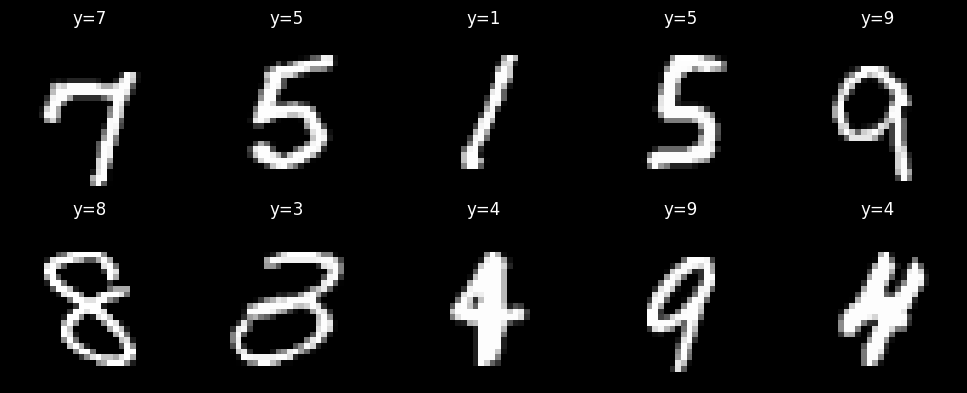

In [11]:
plt.figure(figsize=(10, 4))

for i in range(10):
    idx = np.random.randint(0, X.shape[0])
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx].reshape(28, 28), cmap="gray")
    plt.title(f"y={y[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

У цьому блоці відображається 10 випадкових зображень із датасету MNIST.

In [12]:
pca = PCA(n_components=3, random_state=0)
X_pca = pca.fit_transform(X)

print("X_pca shape:", X_pca.shape)
print("explained_variance_ratio_:", pca.explained_variance_ratio_)
print("sum(explained_variance_ratio_):", np.sum(pca.explained_variance_ratio_))

X_pca shape: (70000, 3)
explained_variance_ratio_: [0.09746116 0.07155444 0.06149531]
sum(explained_variance_ratio_): 0.23051092


У цьому блоці застосовується метод (PCA) для зменшення розмірності даних.
Початкова розмірність кожного зображення становить 784, а метод PCA дозволяє представити ці дані у просторі трьох головних компонент.
Головні компоненти — це нові змінні, які: є лінійними комбінаціями початкових ознак та максимально зберігають дисперсію даних.
Частка поясненої дисперсії показує, яку частину інформації зберігає кожна головна компонента.
Висновок: метод PCA дозволяэ значно зменшити розмірність даних, зберігши при цьому найбільш важливу інформацію про структуру даних.

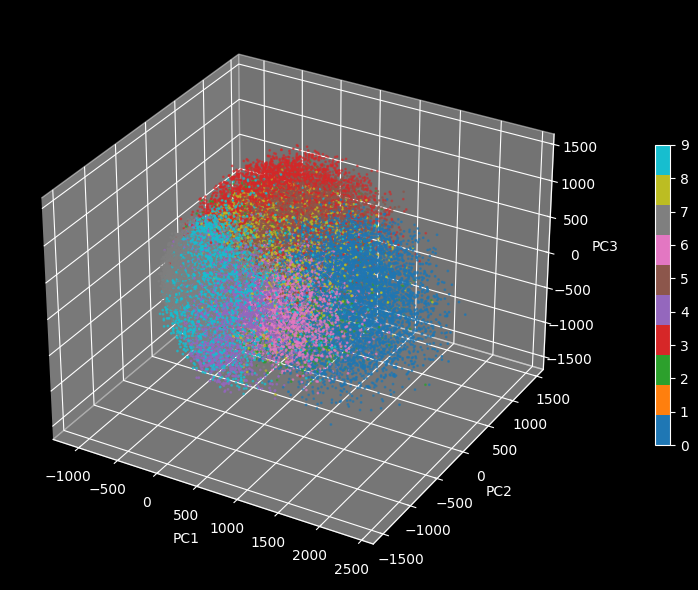

In [13]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
    c=y,
    cmap="tab10",
    s=1
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.colorbar(scatter, ax=ax, fraction=0.02, pad=0.1)
plt.tight_layout()
plt.show()

У цьому блоці будується тривимірний графік, де координатами кожної точки є: PC1 — перша головна компонента, PC2 — друга головна компонента, PC3 — третя головна компонента. Колір точки відповідає цифрі. Графік дозволяє побачити структуру даних у просторі меншої розмірності.
На ньому можна спостерігати формування кластерів для деяких цифр, а також часткове перекриття класів.
Висновки: перекриття виникає через схожість форми деяких цифр та різні стилі їх написання. Навіть після  зменшення розмірності PCA зберігає основну структуру даних, що дозволяє частково розділити класи у новому просторі ознак.

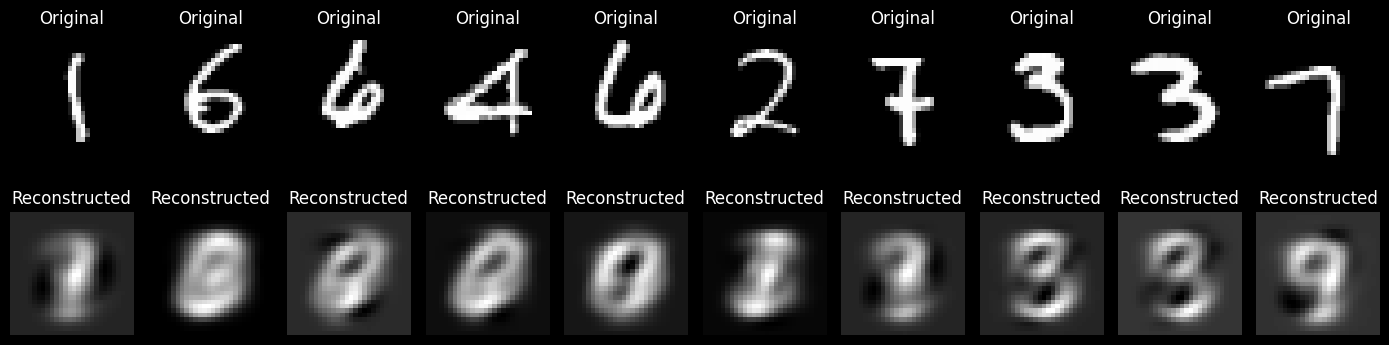

In [14]:
X_reconstructed = pca.inverse_transform(X_pca)

plt.figure(figsize=(14, 4))

for i in range(10):
    idx = np.random.randint(0, X.shape[0])

    plt.subplot(2, 10, i + 1)
    plt.imshow(X[idx].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, 10, i + 11)
    plt.imshow(X_reconstructed[idx].reshape(28, 28), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

У цьому блоці виконується реконструкція зображень після зменшення розмірності.
Спочатку ми робимо проєкцію даних в простір головних компонент, а потім зворотне перетворення.
Висновки: реконструйовані зображення зазвичай виглядають більш розмитими. Це відбувається тому, що лише 3 компоненти не можуть зберегти всю інформацію, тому частина інформації втрачається.Чим менше компонент використовується, тим більша втрата деталей.

In [ ]:
components = [1, 2, 5, 10, 20, 50, 100]

mse_values = []
explained_values = []

for k in components:
    pca_k = PCA(n_components=k, random_state=0)

    X_pca_k = pca_k.fit_transform(X)
    X_reconstructed_k = pca_k.inverse_transform(X_pca_k)

    mse_k = mean_squared_error(X, X_reconstructed_k)
    explained_k = np.sum(pca_k.explained_variance_ratio_)

    mse_values.append(mse_k)
    explained_values.append(explained_k)

У цьому блоці досліджується вплив кількості головних компонент на якість реконструкції.
Для різних значень k ми виконуємо такі дії: PCA, реконструюємо дані, обчислюємо помилку реконструкції MSE(k). Також обчислюємо сумарну пояснену дисперсію EV(k).
Висновки:Зі збільшенням кількості компонент якість реконструкції покращується, але збільшується складність моделі.


In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(components, mse_values, marker="o")
plt.xlabel("k (number of components)")
plt.ylabel("MSE(k)")
plt.title("Reconstruction Error")

plt.subplot(1, 2, 2)
plt.plot(components, explained_values, marker="o")
plt.xlabel("k (number of components)")
plt.ylabel("Explained variance (sum)")
plt.title("Explained Variance vs k")

plt.tight_layout()
plt.show()

MSE(k) — показує, як змінюється помилка реконструкції залежно від кількості компонент.
EV(k) — показує, яку частку дисперсії пояснюють перші k компонент.
Висновки: зі збільшенням k помилка реконструкції зменшується, а сумарна пояснена дисперсія зростає. Графіки нам дозволяють визначити оптимальну кількість компонент, які забезпечують хороший баланс між зменшенням розмірності та збереженням інформації.